In [1]:
import ROOT
import mplhep as hep
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from dataclasses import dataclass, field

import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter

Welcome to JupyROOT 6.30/02


In [2]:
@dataclass
class EffiVar:
    name: str
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    title: str

effivars = [
    EffiVar('pt', 0, 0, 200, 1.1, ";Electron p_{T} (GeV);Efficiency"),
    # EffiVar('eta', -3, 0, 3, 1.1, ";Muon #eta;Efficiency"),
    # EffiVar('HT', 0, 0, 1000, 1.1, ";HT (GeV);Efficiency"),
    # EffiVar('npv', 0, 0, 100, 1.1, ";Nr. of Primary Vertices;Efficiency"),
    # EffiVar('npv_good', 0, 0, 100, 1.1, ";Nr. of Good Primary Vertices;Efficiency")
]

@dataclass
class Selection:
    name: str
    label: str
    input_file: ROOT.TFile
    hist: dict[str, ROOT.TH1] = field(default_factory=dict)
    effi: ROOT.TEfficiency = field(default=None)
    def __post_init__(self):
        self.hist = {effivar.name: self.input_file.Get(f'{self.name}_{effivar.name}') for effivar in effivars}

In [3]:
def extract_tefficiency(teff):
    hist = teff.GetTotalHistogram()
    n_bins = hist.GetNbinsX()
    data = [
        (
            hist.GetBinCenter(i),
            hist.GetBinWidth(i),
            teff.GetEfficiency(i),
            teff.GetEfficiencyErrorLow(i),
            teff.GetEfficiencyErrorUp(i)
        )
        for i in range(1, n_bins + 1)
    ]
    bin_centers, bin_widths, effs, err_low, err_up = map(np.array, zip(*data))
    valid = ~np.isnan(effs) & ~np.isnan(err_low) & ~np.isnan(err_up) & (effs > 0)
    return bin_centers[valid], bin_widths[valid], effs[valid], err_low[valid], err_up[valid]

In [4]:
ylabel = "L1 + HLT Efficiency"
label_fontsize = 24
tick_fontsize = 20
rlabel = "13.6 TeV"
legend_fontsize = 18
legend_loc = "center right"

In [7]:
def plot_effis_and_ratio(input_file, outdir, lep):
    pt_var = effivars[0]

    if lep == 'muon':
        OR_of_existing = Selection("SL_mu_HLT_All", "OR of existing triggers (Mu24 OR\nMu15+HT450 OR HT280+4jet+2btag)", input_file)
        New_trigger_ORed = Selection("SL_mu_HLT_Mu12_IsoVVL_PFHT150_PNetBTag_0p53_OR_All", "New trigger (Mu12+HT150+1btag) OR'ed \nwith existing triggers", input_file)
        denominator_selection = Selection("SL_mu", "No triggers", input_file)
        pt_hist_name = f"SL_mu_{pt_var.name}_Uniform4_start10"
    elif lep == 'electron':
        OR_of_existing = Selection("SL_e_HLT_All", "OR of existing triggers (Ele30 OR\nEle15+HT450 OR HT280+4jet+2btag)", input_file)
        New_trigger_ORed = Selection("SL_e_HLT_Ele14_eta2p5_IsoVVVL_Gsf_HT200_PNetBTag_0p53_OR_All", "New trigger (Ele14+HT200+1btag) OR'ed \nwith existing triggers", input_file)
        denominator_selection = Selection("SL_e", "No triggers", input_file)
        pt_hist_name = f"SL_e_{pt_var.name}_Uniform4_start10"

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_eff = plt.subplot(gs[0])
    ax_ratio = plt.subplot(gs[1], sharex=ax_eff)

    # Efficiency curves ==============================
    OR_of_existing.effi = ROOT.TEfficiency(OR_of_existing.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers, bin_widths, eff1, _, _ = extract_tefficiency(OR_of_existing.effi)
    New_trigger_ORed.effi = ROOT.TEfficiency(New_trigger_ORed.hist[pt_var.name], denominator_selection.hist[pt_var.name])
    bin_centers2, bin_widths2, eff2, _, _ = extract_tefficiency(New_trigger_ORed.effi)
    ax_eff.errorbar(bin_centers, eff1, xerr=bin_widths / 2, fmt='^', color='black', label=OR_of_existing.label, markersize=4)
    ax_eff.errorbar(bin_centers2, eff2, xerr=bin_widths2 / 2, fmt='s', color='red', label=New_trigger_ORed.label, markersize=4)
    ax_eff.set_ylabel("L1 + HLT Efficiency", fontsize=label_fontsize)
    ax_eff.set_ylim(0, 1.1)
    ax_eff.set_xlim(0, 200)
    ax_eff.grid(True)
    ax_eff.tick_params(axis='x', labelsize=tick_fontsize, labelbottom=False)

    # Pre-trigger distribution ==============================
    pt_hist = input_file.Get(pt_hist_name)
    
    n_bins = pt_hist.GetNbinsX()
    bin_edges = np.array([pt_hist.GetBinLowEdge(i + 1) for i in range(n_bins)] + [pt_hist.GetBinLowEdge(n_bins + 1)])
    bin_contents = np.array([pt_hist.GetBinContent(i + 1) for i in range(n_bins)])
    integral = pt_hist.Integral("width")
    bin_contents_norm = bin_contents / integral

    ax_eff_bar = ax_eff.twinx()
    ax_eff_bar.fill_between(bin_edges[:-1], bin_contents_norm, step='post', color='gray', alpha=0.3, label='Pre-trigger distribution')
    
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))  # force scientific notation in a wide range
    ax_eff_bar.yaxis.set_major_formatter(formatter)
    
    ax_eff_bar.yaxis.label.set_color('gray')
    ax_eff_bar.set_ylabel("a.u. (normalized)", fontsize=label_fontsize)
    # ymax = np.max(bin_contents_norm)*1.2
    ymax_for_both = 0.02115667412357516
    ax_eff_bar.set_yticks(np.arange(0, ymax_for_both, 0.005))
    ax_eff_bar.set_ylim(0, ymax_for_both)
    ax_eff_bar.tick_params(axis='y', labelsize=tick_fontsize, colors='gray')
    ax_eff_bar.tick_params(axis='y', which='minor', color='gray', labelcolor='gray')
    ax_eff_bar.yaxis.get_offset_text().set_x(0.1)
    ax_eff_bar.yaxis.get_offset_text().set_horizontalalignment('left')
    ax_eff_bar.yaxis.offsetText.set_position((1, 1.01))

    # Combine and make one legend ===========================
    handles_eff, labels_eff = ax_eff.get_legend_handles_labels()
    handles_bar, labels_bar = ax_eff_bar.get_legend_handles_labels()
    all_legend_handles = handles_eff + handles_bar
    all_legend_labels = labels_eff + labels_bar
    ax_eff_bar.legend(all_legend_handles, all_legend_labels, loc=legend_loc, fontsize=legend_fontsize, frameon=True)
    
    ax_eff.text(
        0.62, 0.28,
        r"$HH \rightarrow b\bar{b}WW*$",
        transform=ax_eff.transAxes,
        fontsize=label_fontsize,
        verticalalignment='top',
        fontdict={'style': 'italic'}
    )
    ax_eff.text(
        0.62, 0.18,
        r"2024 Simulation",
        transform=ax_eff.transAxes,
        fontsize=label_fontsize,
        verticalalignment='top',
        fontdict={'style': 'italic'}
    )
        
    hep.cms.label("Preliminary", data=False, rlabel=rlabel, ax=ax_eff)

    # Ratio plot ===========================================
    ratio = np.divide(eff2, eff1, out=np.full_like(eff1, np.nan), where=eff1 != 0)
    ax_ratio.errorbar(bin_centers, ratio, 
                      fmt='o', color='blue', markersize=5, capsize=2,
                      label="New Trigger Strategy/Existing Trigger Strategy")
    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax_ratio.set_xlabel(f"Offline {lep} $p_T$ (GeV)", fontsize=label_fontsize)
    ax_ratio.set_ylabel("Ratio", fontsize=label_fontsize)

    ylim_up = 3.2
    yticks = np.arange(1.0, 3.01, 0.5)
    ax_ratio.set_ylim(0.8, ylim_up)
    ax_ratio.set_yticks(yticks)
    ax_ratio.grid(True)
    ax_ratio.tick_params(axis='x', labelsize=tick_fontsize)
    ax_ratio.tick_params(axis='y', labelsize=tick_fontsize)
    ax_ratio.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=True)

    plt.tight_layout()
    plt.savefig(f"{outdir}/SL_{'e' if lep=='electron' else 'mu'}_effi_{pt_var.name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

/tmp/anunezde/ipykernel_3365694/3902667443.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


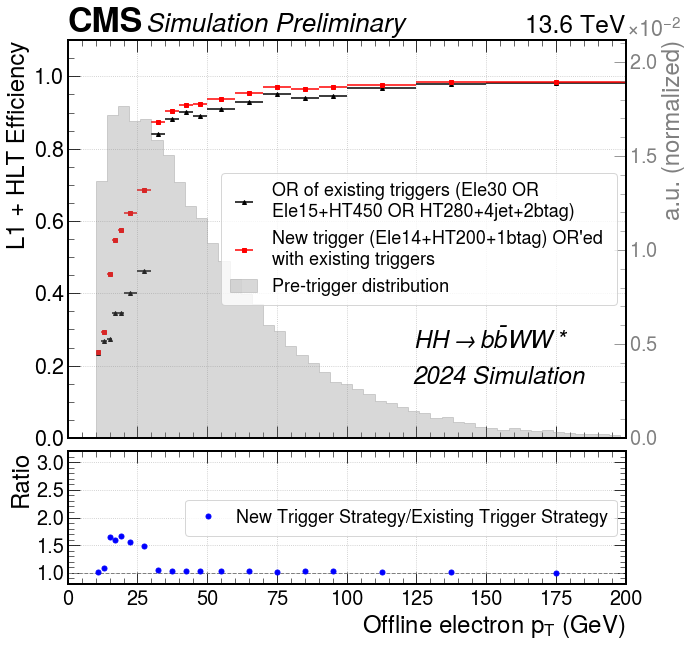

/tmp/anunezde/ipykernel_3365694/3902667443.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


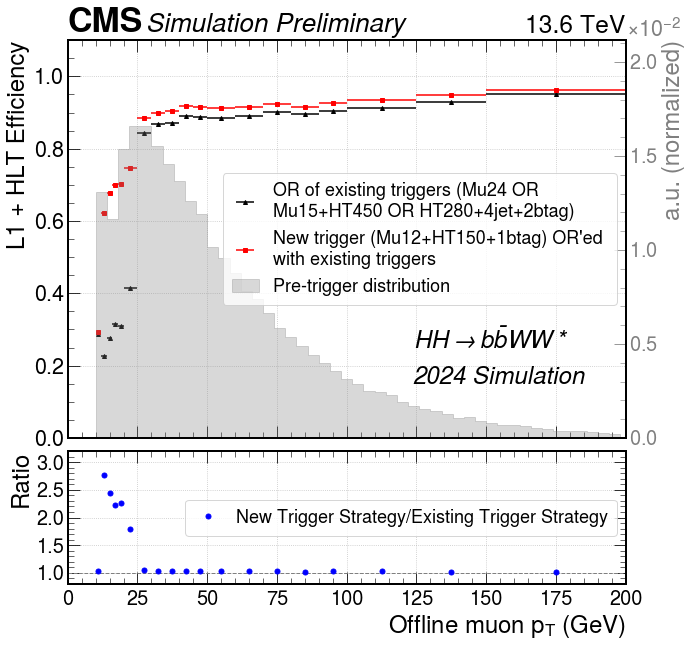

Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Warning in <TEfficiency::GetEfficiencyErrorLow>: frequentist confidence intervals for weights are only supported by the normal approximation
Info in <TEfficiency::GetEfficiencyErrorLow>: setting statistic option to kFNormal
Info in <TEfficiency::TEfficiency>: given histograms are filled with weights
Info in <TROOT::TEfficiency::SetUseWeightedEvents>: Handle weighted events for computing efficiency
Warning in <TEfficien

In [8]:
hep.style.use("CMS")

workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Triggers/Triggers_HLT_10GeV')
signal_file = workdir / 'results' / 'bbWW_sl.root'
input_file = ROOT.TFile.Open(str(signal_file))

outdir = workdir / 'Effi_plots'
outdir.mkdir(parents=True, exist_ok=True)

plot_effis_and_ratio(input_file, outdir, 'electron')
plot_effis_and_ratio(input_file, outdir, 'muon')